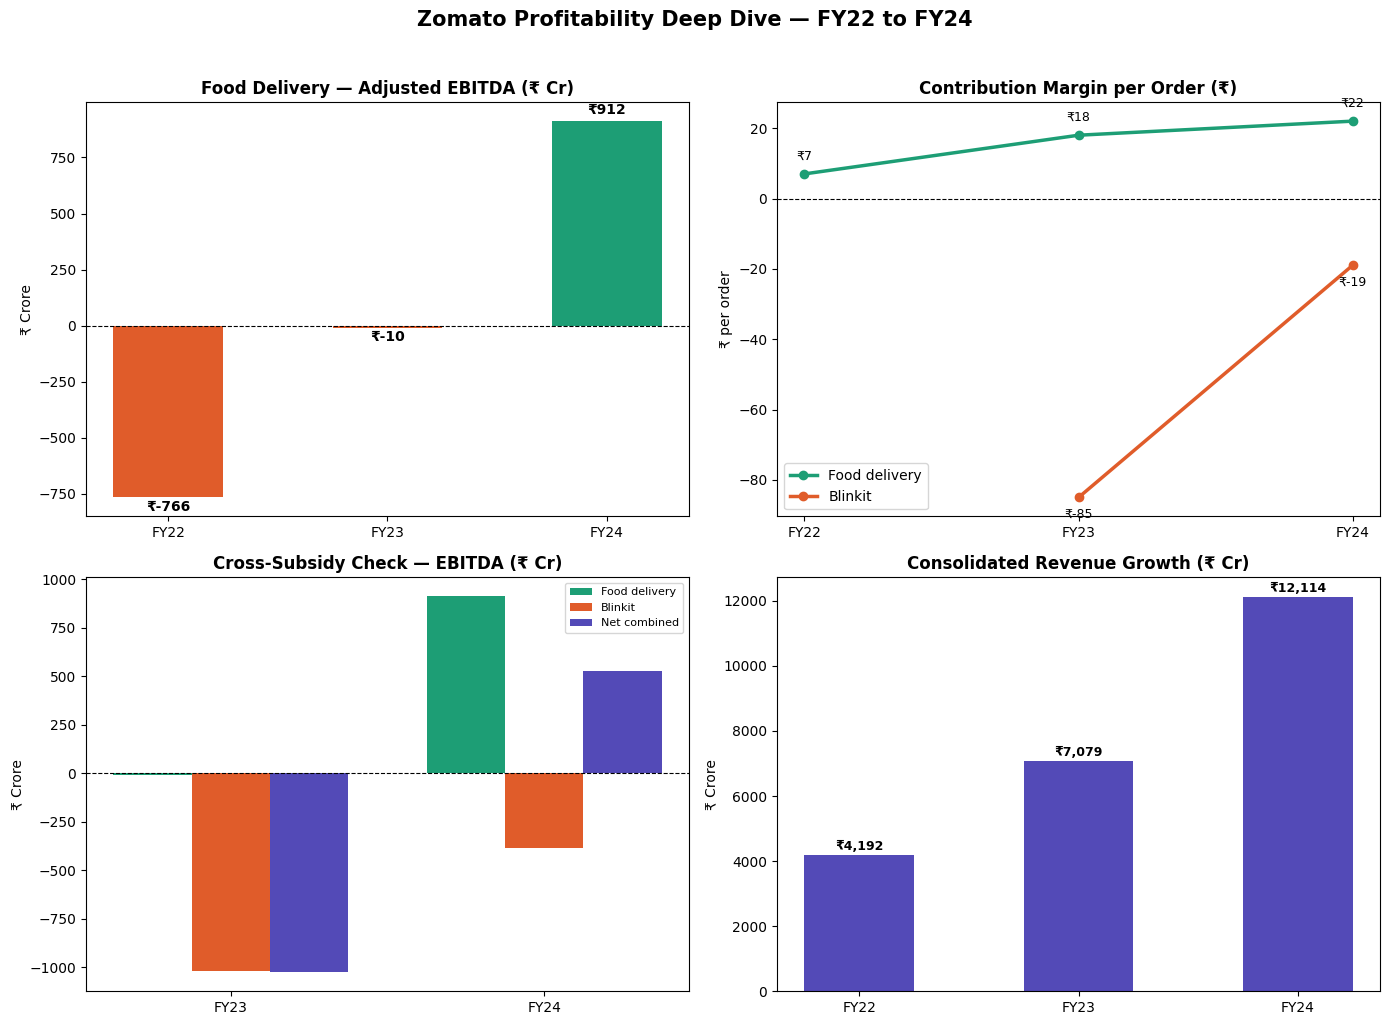

Charts saved as zomato_analysis.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Your data from SQL results
data = {
    'year': ['FY22', 'FY23', 'FY24'],
    'food_ebitda': [-766, -10, 912],
    'blinkit_ebitda': [None, -1016, -384],
    'food_cm_per_order': [7, 18, 22],
    'blinkit_cm_per_order': [None, -85, -19],
    'total_revenue': [4192, 7079, 12114],
    'cash_reserves': [None, 7782, 12241]
}
df = pd.DataFrame(data)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Zomato Profitability Deep Dive — FY22 to FY24',
             fontsize=15, fontweight='bold', y=1.02)

colors_food   = ['#E05C2A' if x < 0 else '#1D9E75' for x in df['food_ebitda']]
colors_blinkit = ['#E05C2A', '#E05C2A']

# Chart 1 — Food delivery EBITDA trend
ax1 = axes[0, 0]
bars = ax1.bar(df['year'], df['food_ebitda'], color=colors_food, width=0.5)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_title('Food Delivery — Adjusted EBITDA (₹ Cr)', fontweight='bold')
ax1.set_ylabel('₹ Crore')
for bar, val in zip(bars, df['food_ebitda']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (30 if val >= 0 else -60),
             f'₹{val}', ha='center', fontsize=10, fontweight='bold')

# Chart 2 — Per order contribution margin
ax2 = axes[0, 1]
ax2.plot(['FY22','FY23','FY24'], [7,18,22],
         marker='o', color='#1D9E75', linewidth=2.5, label='Food delivery')
ax2.plot(['FY23','FY24'], [-85,-19],
         marker='o', color='#E05C2A', linewidth=2.5, label='Blinkit')
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_title('Contribution Margin per Order (₹)', fontweight='bold')
ax2.set_ylabel('₹ per order')
ax2.legend()
for x, y in zip(['FY22','FY23','FY24'], [7,18,22]):
    ax2.annotate(f'₹{y}', (x, y), textcoords='offset points',
                 xytext=(0,10), ha='center', fontsize=9)
for x, y in zip(['FY23','FY24'], [-85,-19]):
    ax2.annotate(f'₹{y}', (x, y), textcoords='offset points',
                 xytext=(0,-15), ha='center', fontsize=9)

# Chart 3 — Cross subsidy
ax3 = axes[1, 0]
x = ['FY23', 'FY24']
food  = [-10, 912]
blink = [-1016, -384]
net   = [-1026, 528]
w = 0.25
xpos = range(len(x))
ax3.bar([p - w for p in xpos], food,  width=w, label='Food delivery', color='#1D9E75')
ax3.bar([p     for p in xpos], blink, width=w, label='Blinkit',       color='#E05C2A')
ax3.bar([p + w for p in xpos], net,   width=w, label='Net combined',  color='#534AB7')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax3.set_title('Cross-Subsidy Check — EBITDA (₹ Cr)', fontweight='bold')
ax3.set_xticks(list(xpos)); ax3.set_xticklabels(x)
ax3.set_ylabel('₹ Crore')
ax3.legend(fontsize=8)

# Chart 4 — Revenue growth
ax4 = axes[1, 1]
ax4.bar(df['year'], df['total_revenue'], color='#534AB7', width=0.5)
ax4.set_title('Consolidated Revenue Growth (₹ Cr)', fontweight='bold')
ax4.set_ylabel('₹ Crore')
for i, (yr, rev) in enumerate(zip(df['year'], df['total_revenue'])):
    ax4.text(i, rev + 150, f'₹{rev:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('zomato_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved as zomato_analysis.png")